# ToolFinder Dataset: Exploratory Data Analysis

This notebook documents the query/schema corpus used by the ToolFinder
experiments. Source data: `academic_research/mcp_routing_dataset{,_v2}.csv`,
annotated with recovered scenario structure by
`experiments/dataset/annotate_scenarios.py`.

Key facts established below:

1. **Composition** — 1,500 queries over 30 GitHub MCP tools (15 train-eligible,
   15 reserved for unseen-tool evaluation), perfectly balanced at 50 queries/tool.
2. **Generation structure** — most tools follow a `scenario x template` grammar
   (~5 scenarios x ~10 paraphrase templates), which is exactly why random row
   splits leak: paraphrases of one scenario land on both sides of the split.
3. **Leakage audit** — under the original random split, a trivial 1-NN lookup
   over training anchors scores ~96% Recall@1; the scenario-grouped split
   removes this artifact.
4. **Lexical overlap** — queries share substantial vocabulary with their target
   schemas (tool-name echo), which is why BM25/TF-IDF are mandatory baselines.


In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

queries = pd.read_csv(REPO_ROOT / "experiments/data/queries_with_scenarios.csv")
corpus = json.loads((REPO_ROOT / "experiments/data/corpus.json").read_text(encoding="utf-8"))
print(f"queries: {len(queries)} | tools: {queries['tool'].nunique()} | scenarios: {queries['scenario_id'].nunique()}")
queries.head(3)

queries: 1500 | tools: 30 | scenarios: 235


,query_id,dataset,server,tool,scenario_id,origin,anchor,positive_schema
0,v1-0000,v1,github,search_repositories,v1:search_repositories:s15,author_template,Search for repositories matching machine learn...,"{""name"":""search_repositories"",""description"":""F..."
1,v1-0001,v1,github,search_repositories,v1:search_repositories:s05,author_template,Find GitHub repos about vector databases with ...,"{""name"":""search_repositories"",""description"":""F..."
2,v1-0002,v1,github,search_repositories,v1:search_repositories:s48,author_template,Search repositories tagged with kubernetes and...,"{""name"":""search_repositories"",""description"":""F..."


## 1. Dataset card: composition and balance

In [2]:
card = queries.groupby("dataset").agg(
    n_queries=("query_id", "count"),
    n_tools=("tool", "nunique"),
    n_scenarios=("scenario_id", "nunique"),
)
card["queries_per_tool"] = card["n_queries"] // card["n_tools"]
card

,n_queries,n_tools,n_scenarios,queries_per_tool
dataset,,,,
v1,750,15,160,50
v2,750,15,75,50


In [3]:
per_tool = queries.groupby(["dataset", "tool"]).agg(
    rows=("query_id", "count"), scenarios=("scenario_id", "nunique")
).reset_index()
print("Scenario counts per tool (5 = templated 5x10 grammar; ~50 = one scenario per row):")
per_tool.groupby(["dataset", "scenarios"]).size().rename("n_tools").reset_index()

Scenario counts per tool (5 = templated 5x10 grammar; ~50 = one scenario per row):


,dataset,scenarios,n_tools
0,v1,5,13
1,v1,46,1
2,v1,49,1
3,v2,5,15


## 2. Query length distribution

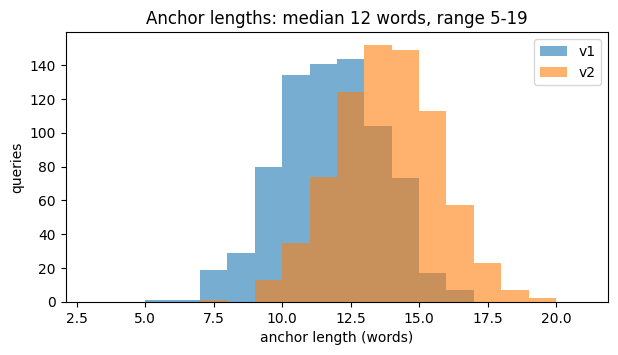

In [4]:
lengths = queries["anchor"].str.split().str.len()
fig, ax = plt.subplots(figsize=(7, 3.5))
for dataset, group in queries.groupby("dataset"):
    ax.hist(group["anchor"].str.split().str.len(), bins=range(3, 22), alpha=0.6, label=dataset)
ax.set_xlabel("anchor length (words)"); ax.set_ylabel("queries"); ax.legend()
ax.set_title(f"Anchor lengths: median {int(lengths.median())} words, range {lengths.min()}-{lengths.max()}")
plt.show()

## 3. The scenario x template grammar (why random splits leak)

One concrete scenario group: the same scenario clause rendered through ten
different prefixes. Any split that separates rows instead of scenarios puts
near-duplicates of every test query into training.

In [5]:
example_scenario = (
    queries[queries["tool"] == "create_or_update_file"].groupby("scenario_id").size().idxmax()
)
for anchor in queries[queries["scenario_id"] == example_scenario]["anchor"]:
    print(" -", anchor)

 - Create or update a repository file to create an environment config file.
 - Write a file change in the repo to create an environment config file.
 - Commit a single file update to create an environment config file.
 - Can you create or update a file to create an environment config file?
 - Could you make a repository file change to create an environment config file?
 - Would you update one file so it can create an environment config file?
 - Can this repo get a file edit to create an environment config file?
 - I need to change one file in the repo to create an environment config file.
 - I want a direct file update that will create an environment config file.
 - I am preparing a repository file change to create an environment config file.


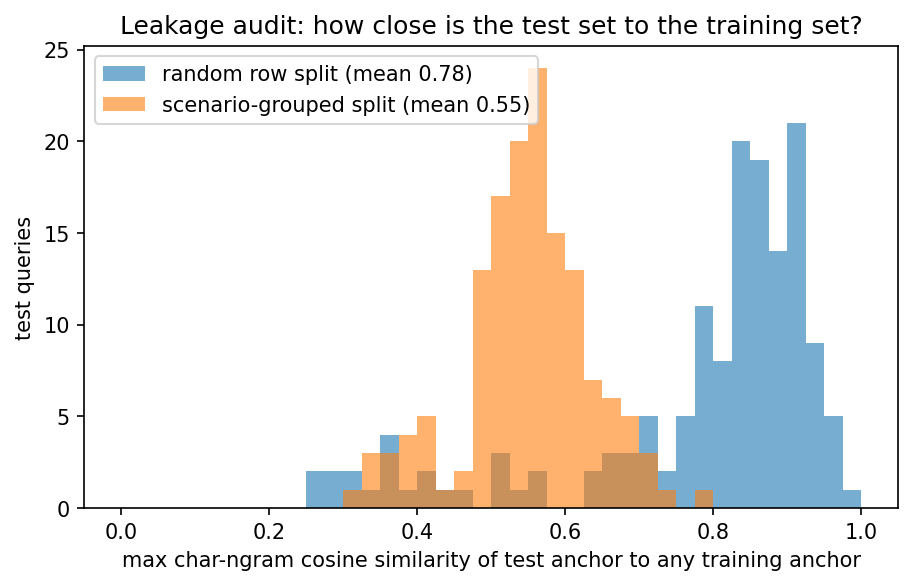

In [6]:
from IPython.display import Image, display
figure_path = REPO_ROOT / "experiments/results/figures/fig_leakage_audit.png"
if figure_path.exists():
    display(Image(str(figure_path)))
else:
    print("run experiments/figures.py first")

## 4. Query-schema lexical overlap (why lexical baselines are mandatory)

Fraction of each query's content words that also appear in its target schema
text. High overlap means part of the task is solvable by string matching, so
dense models must be read as deltas over BM25/TF-IDF, not in isolation.

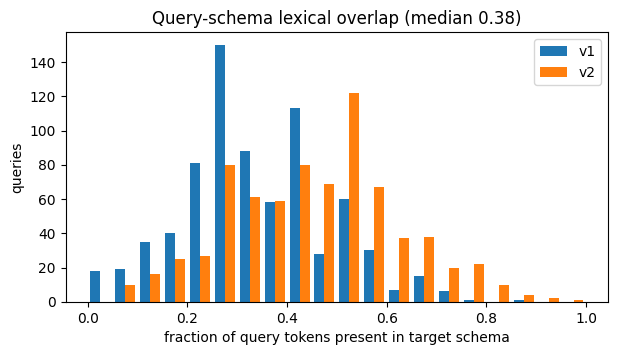

median overlap v1: 0.33 | v2: 0.45


In [7]:
import re

def tokens(text):
    return set(re.findall(r"[a-z0-9]+", text.lower().replace("_", " ")))

schema_tokens = {tool: tokens(json.dumps(entry["schema"])) for tool, entry in corpus.items()}
overlap = queries.apply(
    lambda row: len(tokens(row["anchor"]) & schema_tokens[row["tool"]]) / max(1, len(tokens(row["anchor"]))),
    axis=1,
)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist([overlap[queries["dataset"] == "v1"], overlap[queries["dataset"] == "v2"]],
        bins=20, label=["v1", "v2"])
ax.set_xlabel("fraction of query tokens present in target schema"); ax.set_ylabel("queries")
ax.set_title(f"Query-schema lexical overlap (median {overlap.median():.2f})"); ax.legend()
plt.show()
print(f"median overlap v1: {overlap[queries['dataset']=='v1'].median():.2f} | "
      f"v2: {overlap[queries['dataset']=='v2'].median():.2f}")

## 5. Inter-tool schema confusability

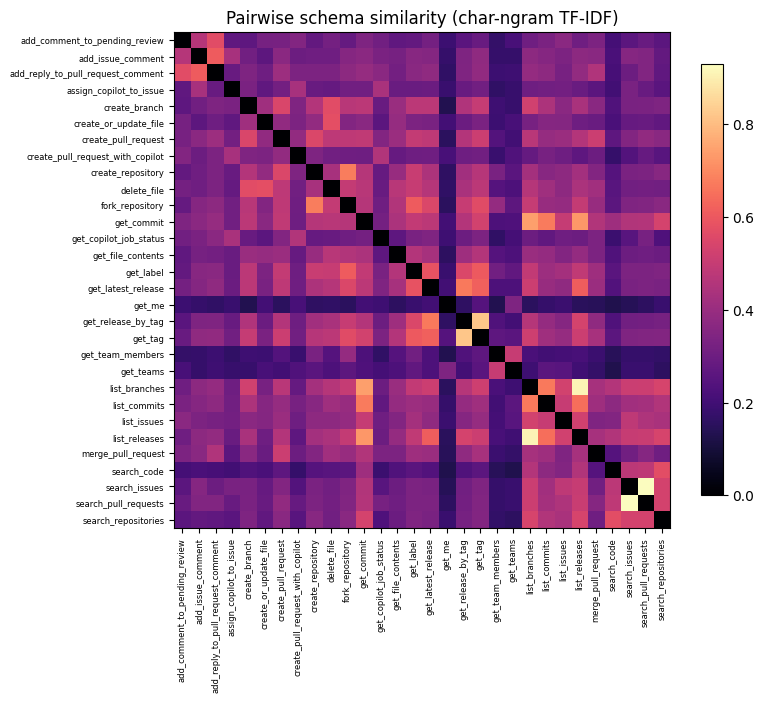

Most confusable schema pairs:
  0.93  search_issues <-> search_pull_requests
  0.91  list_branches <-> list_releases
  0.82  get_release_by_tag <-> get_tag
  0.74  get_commit <-> list_branches
  0.73  get_commit <-> list_releases


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tools_sorted = sorted(corpus)
schema_texts = [json.dumps(corpus[t]["schema"], sort_keys=True) for t in tools_sorted]
matrix = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5)).fit_transform(schema_texts)
similarity = cosine_similarity(matrix)
np.fill_diagonal(similarity, 0)

fig, ax = plt.subplots(figsize=(8, 7))
image = ax.imshow(similarity, cmap="magma")
ax.set_xticks(range(30)); ax.set_xticklabels(tools_sorted, rotation=90, fontsize=6)
ax.set_yticks(range(30)); ax.set_yticklabels(tools_sorted, fontsize=6)
ax.set_title("Pairwise schema similarity (char-ngram TF-IDF)")
fig.colorbar(image, shrink=0.8)
plt.show()

pairs = [(tools_sorted[i], tools_sorted[j], similarity[i, j])
         for i in range(30) for j in range(i + 1, 30)]
print("Most confusable schema pairs:")
for a, b, s in sorted(pairs, key=lambda p: -p[2])[:5]:
    print(f"  {s:.2f}  {a} <-> {b}")

## 6. Split summary

Splits are scenario-grouped (regime 1) and tool-disjoint (regime 2); the
hygiene constraints are enforced by `tests/test_split_hygiene.py` in CI.

In [9]:
for regime in ("regime1_unseen_queries", "regime2_unseen_tools"):
    spec = json.loads((REPO_ROOT / f"experiments/data/splits/{regime}.json").read_text(encoding="utf-8"))
    print(f"{regime}: train={len(spec['train'])} val={len(spec['val'])} test={len(spec['test'])} "
          f"corpus={len(spec['corpus_tools'])} tools")

regime1_unseen_queries: train=460 val=146 test=144 corpus=30 tools
regime2_unseen_tools: train=460 val=146 test=750 corpus=30 tools
